# Classifier combination study — 4 × 2

Each of the two pipeline architectures is tested with four classifier combinations at Stage 1 and Stage 2:

| Combo | Stage 1 | Stage 2 |
|---|---|---|
| LR + LR | Logistic Regression | Logistic Regression |
| LR + NB | Logistic Regression | Naive Bayes |
| NB + LR | Naive Bayes | Logistic Regression |
| NB + NB | Naive Bayes | Naive Bayes |

The TF-IDF vectorizers from notebooks 01 and 02 are reused — only the classifiers change, so the feature space stays consistent. Primary metric: macro F1. Secondary: phishing→ham count.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, recall_score
from matplotlib.patches import Patch

BASE = "../.."

In [2]:
test  = pd.read_csv(f"{BASE}/data/processed/07/test_data.csv")
X_test, y_test = test["message"], test["label"]

stage1a_train = pd.read_csv(f"{BASE}/data/processed/07/stage1a_train.csv")
stage2a_train = pd.read_csv(f"{BASE}/data/processed/07/stage2a_train.csv")
stage1b_train = pd.read_csv(f"{BASE}/data/processed/07/stage1b_train.csv")
stage2b_train = pd.read_csv(f"{BASE}/data/processed/07/stage2b_train.csv")

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

m = f"{BASE}/models/07"
s1a_vec = load_pkl(f"{m}/stage1a_vectorizer.pkl")
s2a_vec = load_pkl(f"{m}/stage2a_vectorizer.pkl")
s1b_vec = load_pkl(f"{m}/stage1b_vectorizer.pkl")
s2b_vec = load_pkl(f"{m}/stage2b_vectorizer.pkl")

print("test:", len(test), "| stage1a_train:", len(stage1a_train), "| stage1b_train:", len(stage1b_train))

test: 101877 | stage1a_train: 407507 | stage1b_train: 407507


In [3]:
def predict_pipeline_a(messages, s1_model, s1_vec, s2_model, s2_vec):
    messages = pd.Series(messages).reset_index(drop=True)
    preds    = pd.Series([None] * len(messages), dtype=object)
    s1_out   = s1_model.predict(s1_vec.transform(messages))
    preds[s1_out == "normal"] = "ham"
    idx = np.where(s1_out == "not_normal")[0]
    if len(idx) > 0:
        s2_out = s2_model.predict(s2_vec.transform(messages.iloc[idx]))
        for i, p in zip(idx, s2_out):
            preds[i] = p
    return preds.values


def predict_pipeline_b(messages, s1_model, s1_vec, s2_model, s2_vec):
    messages = pd.Series(messages).reset_index(drop=True)
    preds    = pd.Series([None] * len(messages), dtype=object)
    s1_out   = s1_model.predict(s1_vec.transform(messages))
    preds[s1_out == "phishing"] = "phishing"
    idx = np.where(s1_out == "not_phishing")[0]
    if len(idx) > 0:
        s2_out = s2_model.predict(s2_vec.transform(messages.iloc[idx]))
        for i, p in zip(idx, s2_out):
            preds[i] = p
    return preds.values


def make_clf(name):
    if name == "LR":
        return LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    return MultinomialNB(alpha=1.0)


def metrics_row(y_true, y_pred, combo):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ph_total  = int((y_true == "phishing").sum())
    ph_as_ham = int(((y_true == "phishing") & (y_pred == "ham")).sum())
    return {
        "combo":           combo,
        "accuracy":        round(accuracy_score(y_true, y_pred), 4),
        "macro_f1":        round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "phishing_recall": round(recall_score(y_true, y_pred, labels=["phishing"], average="micro", zero_division=0), 4),
        "ham_recall":      round(recall_score(y_true, y_pred, labels=["ham"],      average="micro", zero_division=0), 4),
        "phishing→ham":    ph_as_ham,
        "ph→ham %":        round(100 * ph_as_ham / ph_total, 1),
    }

## Architecture A — four classifier combinations

Stage 1A splits ham | not_normal; Stage 2A splits spam | phishing. The saved vectorizers are reused — TF-IDF matrices are precomputed once to avoid redundant transforms across the four combinations.

In [4]:
S1A_train_tf = s1a_vec.transform(stage1a_train["message"])
S2A_train_tf = s2a_vec.transform(stage2a_train["message"])

archA_rows = []
for s1_name, s2_name in [("LR", "LR"), ("LR", "NB"), ("NB", "LR"), ("NB", "NB")]:
    s1 = make_clf(s1_name);  s1.fit(S1A_train_tf, stage1a_train["label"])
    s2 = make_clf(s2_name);  s2.fit(S2A_train_tf, stage2a_train["label"])
    y_pred = predict_pipeline_a(X_test, s1, s1a_vec, s2, s2a_vec)
    archA_rows.append(metrics_row(y_test, y_pred, f"{s1_name}+{s2_name}"))
    print(f"  {s1_name}+{s2_name} done")

  LR+LR done
  LR+NB done
  NB+LR done
  NB+NB done


In [5]:
archA_df = pd.DataFrame(archA_rows).set_index("combo")
archA_df

,accuracy,macro_f1,phishing_recall,ham_recall,phishing→ham,ph→ham %
combo,,,,,,
LR+LR,0.9520,0.9360,0.8882,0.9656,735,4.3
LR+NB,0.9355,0.9188,0.9256,0.9656,735,4.3
NB+LR,0.9297,0.9042,0.7891,0.9535,2485,14.5
NB+NB,0.9138,0.8891,0.8244,0.9535,2485,14.5


## Architecture B — four classifier combinations

Stage 1B splits phishing | not_phishing; Stage 2B splits ham | spam. The saved vectorizers for Architecture B are used here.

In [6]:
S1B_train_tf = s1b_vec.transform(stage1b_train["message"])
S2B_train_tf = s2b_vec.transform(stage2b_train["message"])

archB_rows = []
for s1_name, s2_name in [("LR", "LR"), ("LR", "NB"), ("NB", "LR"), ("NB", "NB")]:
    s1 = make_clf(s1_name);  s1.fit(S1B_train_tf, stage1b_train["label"])
    s2 = make_clf(s2_name);  s2.fit(S2B_train_tf, stage2b_train["label"])
    y_pred = predict_pipeline_b(X_test, s1, s1b_vec, s2, s2b_vec)
    archB_rows.append(metrics_row(y_test, y_pred, f"{s1_name}+{s2_name}"))
    print(f"  {s1_name}+{s2_name} done")

  LR+LR done
  LR+NB done
  NB+LR done
  NB+NB done


In [7]:
archB_df = pd.DataFrame(archB_rows).set_index("combo")
archB_df

,accuracy,macro_f1,phishing_recall,ham_recall,phishing→ham,ph→ham %
combo,,,,,,
LR+LR,0.9416,0.9204,0.8296,0.9715,1710,10.0
LR+NB,0.9242,0.9058,0.8296,0.9625,2041,11.9
NB+LR,0.9158,0.8905,0.8667,0.9172,1637,9.5
NB+NB,0.9060,0.8824,0.8667,0.9073,1537,9.0


## Best combination for each architecture

Select the combo with the highest macro F1 for each architecture. The final comparison shows whether the best classifier choice differs between architectures and whether it changes which architecture wins overall.

In [8]:
best_a = archA_df["macro_f1"].idxmax()
best_b = archB_df["macro_f1"].idxmax()

print(f"Best for Architecture A: {best_a}  (macro F1 = {archA_df.loc[best_a, 'macro_f1']:.4f})")
print(f"Best for Architecture B: {best_b}  (macro F1 = {archB_df.loc[best_b, 'macro_f1']:.4f})")
print()

final = pd.DataFrame([
    archA_df.loc[best_a].rename(f"A — {best_a}"),
    archB_df.loc[best_b].rename(f"B — {best_b}"),
])
final

Best for Architecture A: LR+LR  (macro F1 = 0.9360)
Best for Architecture B: LR+LR  (macro F1 = 0.9204)



,accuracy,macro_f1,phishing_recall,ham_recall,phishing→ham,ph→ham %
A — LR+LR,0.9520,0.9360,0.8882,0.9656,735.0,4.3
B — LR+LR,0.9416,0.9204,0.8296,0.9715,1710.0,10.0


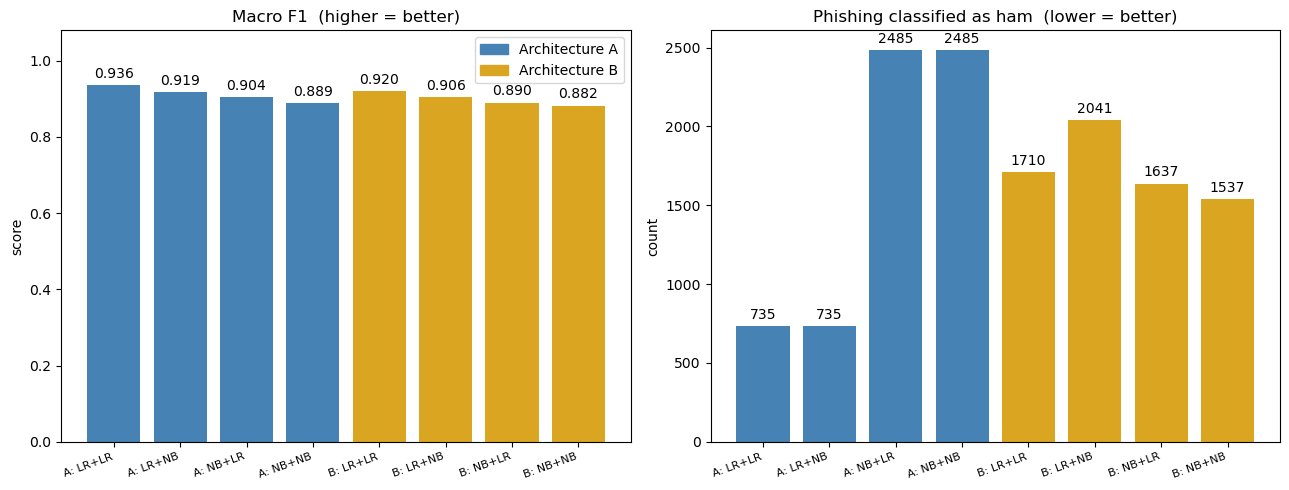

In [9]:
archA_labeled = archA_df.copy()
archA_labeled.index = [f"A: {c}" for c in archA_df.index]
archB_labeled = archB_df.copy()
archB_labeled.index = [f"B: {c}" for c in archB_df.index]

all_rows = pd.concat([archA_labeled, archB_labeled])
colors   = ["steelblue"] * 4 + ["goldenrod"] * 4
x        = range(8)
xlabels  = all_rows.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(x, all_rows["macro_f1"], color=colors)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=20, ha="right", fontsize=8)
ax.set_ylim(0, 1.08)
ax.set_title("Macro F1  (higher = better)")
ax.set_ylabel("score")
ax.legend(handles=[
    Patch(color="steelblue", label="Architecture A"),
    Patch(color="goldenrod", label="Architecture B"),
])

ax = axes[1]
bars = ax.bar(x, all_rows["phishing→ham"], color=colors)
ax.bar_label(bars, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=20, ha="right", fontsize=8)
ax.set_title("Phishing classified as ham  (lower = better)")
ax.set_ylabel("count")

plt.tight_layout()
os.makedirs(f"{BASE}/reports/figures/07", exist_ok=True)
plt.savefig(f"{BASE}/reports/figures/07/classifier_combinations.png", dpi=150, bbox_inches="tight")
plt.show()

The left chart shows overall performance; the right shows undetected phishing. If the rankings disagree, it means there is a trade-off between overall accuracy and phishing safety — which is the expected result and something worth discussing in the final report.